In [1]:
import cv2
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

## Setup

In [2]:
def imshow(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

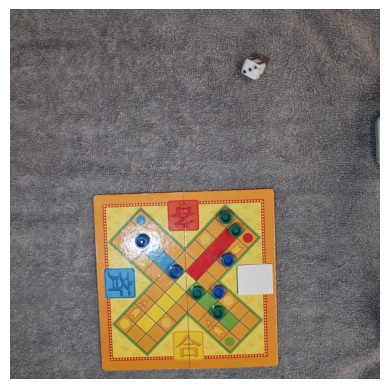

In [3]:
cap = cv2.VideoCapture("data/vid_2_dist=2.mp4")

frame_number = 430  # the frame you want
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()  # read the frame
if not ret:
    cap.release()
    raise RuntimeError(f"Could not read frame {frame_number}")

cap.release()  # release after reading

# Convert BGR → RGB for display
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

code below can be used to find HSV filters to find pawns on the frame

In [4]:
# img_hsv = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2HSV)
# def nothing(x):
#     pass

# cv2.namedWindow("mask")
# cv2.createTrackbar("H min", "mask", 0, 179, nothing)
# cv2.createTrackbar("H max", "mask", 179, 179, nothing)
# cv2.createTrackbar("S min", "mask", 0, 255, nothing)
# cv2.createTrackbar("S max", "mask", 255, 255, nothing)
# cv2.createTrackbar("V min", "mask", 0, 255, nothing)
# cv2.createTrackbar("V max", "mask", 255, 255, nothing)

# while True:
#     h_min = cv2.getTrackbarPos("H min", "mask")
#     h_max = cv2.getTrackbarPos("H max", "mask")
#     s_min = cv2.getTrackbarPos("S min", "mask")
#     s_max = cv2.getTrackbarPos("S max", "mask")
#     v_min = cv2.getTrackbarPos("V min", "mask")
#     v_max = cv2.getTrackbarPos("V max", "mask")

#     lower = np.array([h_min, s_min, v_min])
#     upper = np.array([h_max, s_max, v_max])
#     mask = cv2.inRange(img_hsv, lower, upper)

#     cv2.imshow("mask", mask)
#     if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
#         break

# cv2.destroyAllWindows()

## Create color based pawn mask

In [5]:
def find_green_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_green = np.array([80, 100, 0])
    # upper_green = np.array([100, 255, 80])
    upper_green = np.array([100, 255, 160])

    green_mask = cv2.inRange(frame_hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)

    green_open = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel)
    green_closed = cv2.morphologyEx(green_open, cv2.MORPH_CLOSE, kernel)

    return green_mask


def find_blue_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([108, 100, 60])
    upper_blue = np.array([120, 255, 160])

    blue_mask = cv2.inRange(frame_hsv, lower_blue, upper_blue)

    kernel = np.ones((5, 5), np.uint8)

    blue_open = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel)
    blue_closed = cv2.morphologyEx(blue_open, cv2.MORPH_CLOSE, kernel)

    return blue_mask

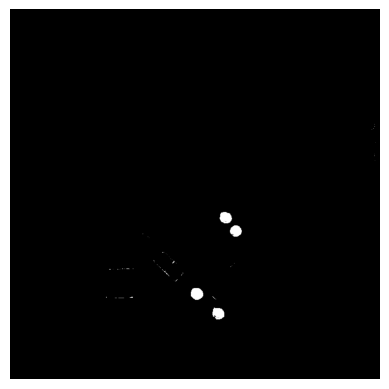

In [6]:
green_mask = find_green_pawns(frame)
imshow(green_mask)

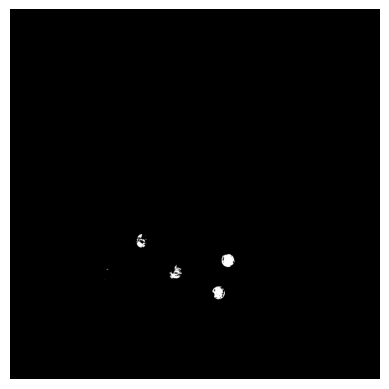

In [7]:
blue_mask = find_blue_pawns(frame)
imshow(blue_mask)

## Mark each pawn by finding connected components

In [8]:
def mark_pawns(mask, min_area=500):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    pawn_centers = []

    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]

        if area < min_area:
            continue

        pawn_centers.append((cx, cy))

    return pawn_centers

def draw_pawn_circles(frame, pawn_centers, color):
    frame = frame.copy()
    for cx, cy in pawn_centers:
        cv2.circle(frame, (int(cx), int(cy)), 15, color, 2)

    imshow(frame)
    return frame

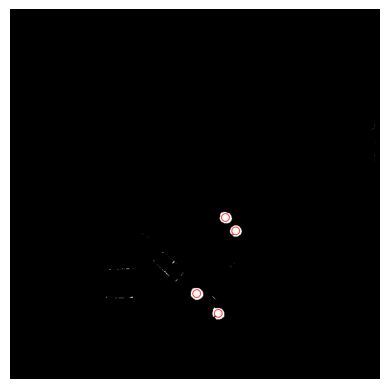

In [9]:
draw_pawn_circles(cv2.cvtColor(green_mask, cv2.COLOR_GRAY2BGR), mark_pawns(find_green_pawns(frame)), (0, 0, 255));

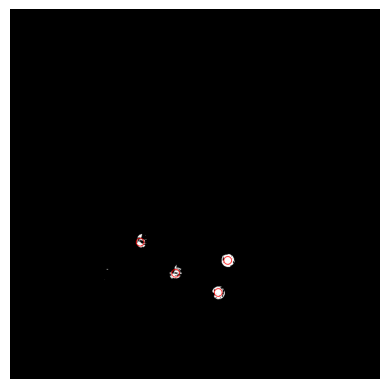

In [10]:
draw_pawn_circles(cv2.cvtColor(blue_mask, cv2.COLOR_GRAY2BGR), mark_pawns(find_blue_pawns(frame)), (0, 0, 255));

## Find pawns on the whole video

In [11]:
cap = cv2.VideoCapture("data/vid_2_dist=1.mp4")

# Video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

green_4_count = 0
blue_4_count = 0
both_4_count = 0
processed_frames = 0

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
output_writer = cv2.VideoWriter("pawns_marked.mp4", fourcc, fps, (width, height))

for _ in tqdm(range(total_frames), desc="Processing video"):
    ret, frame = cap.read()
    if not ret:
        break
        
    mask_green = find_green_pawns(frame)

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_green)
    pawn_centers_green = []

    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]
        min_area = 500
        if area < min_area:
            continue
            
        pawn_centers_green.append((cx, cy))

    mask_blue = find_blue_pawns(frame)

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_blue)
    pawn_centers_blue = []

    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]
        min_area = 500
        if area < min_area:
            continue
            
        pawn_centers_blue.append((cx, cy))

    # Draw detected pawns
    output_frame = frame
    # output_frame = cv2.cvtColor(mask_green+mask_blue, cv2.COLOR_GRAY2BGR)
    for cx, cy in pawn_centers_green:
        cv2.circle(output_frame, (int(cx), int(cy)), 15, (255, 255, 51), 2)
        
    for cx, cy in pawn_centers_blue:
        cv2.circle(output_frame, (int(cx), int(cy)), 15, (0, 0, 255), 2)

    n_green = len(pawn_centers_green)
    n_blue = len(pawn_centers_blue)
    
    processed_frames += 1
    
    if n_green == 4:
        green_4_count += 1
    
    if n_blue == 4:
        blue_4_count += 1
    
    if n_green == 4 and n_blue == 4:
        both_4_count += 1

    output_writer.write(output_frame)

cap.release()
output_writer.release()
print("Finished writing video: pawns_marked.mp4")

Processing video:   0%|          | 0/5881 [00:00<?, ?it/s]

Finished writing video: pawns_marked.mp4


In [12]:
print("Finished writing video: pawns_marked.mp4")

print(f"Total processed frames: {processed_frames}")
print(f"Frames with 4 green pawns visible: {green_4_count}")
print(f"Frames with 4 blue pawns visible: {blue_4_count}")
print(f"Frames with 4 green AND 4 blue pawns visible: {both_4_count}")

print("\nPercentages:")
print(f"4 green visible: {100 * green_4_count / processed_frames:.2f}%")
print(f"4 blue visible: {100 * blue_4_count / processed_frames:.2f}%")
print(f"Both 4 visible: {100 * both_4_count / processed_frames:.2f}%")

Finished writing video: pawns_marked.mp4
Total processed frames: 5881
Frames with 4 green pawns visible: 2646
Frames with 4 blue pawns visible: 4532
Frames with 4 green AND 4 blue pawns visible: 2302

Percentages:
4 green visible: 44.99%
4 blue visible: 77.06%
Both 4 visible: 39.14%


In [13]:
vids = [
       "data/vid_1_dist=1.mp4", "data/vid_2_dist=1.mp4", "data/vid_3_dist=1.mp4",
       "data/vid_1_dist=2.mp4", "data/vid_2_dist=2.mp4", "data/vid_3_dist=2.mp4",
       "data/vid_1_dist=3.mp4", "data/vid_2_dist=3.mp4", "data/vid_3_dist=3.mp4",
]

for vid in vids:

    cap = cv2.VideoCapture(vid)
    
    # Video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    green_4_count = 0
    blue_4_count = 0
    both_4_count = 0
    processed_frames = 0
    
    for _ in tqdm(range(total_frames), desc="Processing video"):
        ret, frame = cap.read()
        if not ret:
            break
            
        mask_green = find_green_pawns(frame)
    
        # Connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_green)
        pawn_centers_green = []
    
        for i in range(1, num_labels):  # skip background
            x, y, w, h, area = stats[i]
            cx, cy = centroids[i]
            min_area = 500
            if area < min_area:
                continue
                
            pawn_centers_green.append((cx, cy))
    
        mask_blue = find_blue_pawns(frame)
    
        # Connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_blue)
        pawn_centers_blue = []
    
        for i in range(1, num_labels):  # skip background
            x, y, w, h, area = stats[i]
            cx, cy = centroids[i]
            min_area = 500
            if area < min_area:
                continue
                
            pawn_centers_blue.append((cx, cy))
    
        n_green = len(pawn_centers_green)
        n_blue = len(pawn_centers_blue)
        
        processed_frames += 1
        
        if n_green == 4:
            green_4_count += 1
        
        if n_blue == 4:
            blue_4_count += 1
        
        if n_green == 4 and n_blue == 4:
            both_4_count += 1
    
    cap.release()
    print(f"Finished reading video: {vid}")
    print("\nPercentages:")
    print(f"4 green visible: {100 * green_4_count / processed_frames:.2f}%")
    print(f"4 blue visible: {100 * blue_4_count / processed_frames:.2f}%")
    print(f"Both 4 visible: {100 * both_4_count / processed_frames:.2f}%")

Processing video:   0%|          | 0/3372 [00:00<?, ?it/s]

Finished reading video: data/vid_1_dist=1.mp4
Total processed frames: 3372
Frames with 4 green pawns visible: 2872
Frames with 4 blue pawns visible: 3004
Frames with 4 green AND 4 blue pawns visible: 2515

Percentages:
4 green visible: 85.17%
4 blue visible: 89.09%
Both 4 visible: 74.58%


Processing video:   0%|          | 0/5881 [00:00<?, ?it/s]

Finished reading video: data/vid_2_dist=1.mp4
Total processed frames: 5881
Frames with 4 green pawns visible: 2646
Frames with 4 blue pawns visible: 4532
Frames with 4 green AND 4 blue pawns visible: 2302

Percentages:
4 green visible: 44.99%
4 blue visible: 77.06%
Both 4 visible: 39.14%


Processing video:   0%|          | 0/6447 [00:00<?, ?it/s]

...

Finished reading video: data/vid_1_dist=3.mp4
Total processed frames: 2496
Frames with 4 green pawns visible: 1626
Frames with 4 blue pawns visible: 2137
Frames with 4 green AND 4 blue pawns visible: 1498

Percentages:
4 green visible: 65.14%
4 blue visible: 85.62%
Both 4 visible: 60.02%


Processing video:   0%|          | 0/8840 [00:00<?, ?it/s]

Finished reading video: data/vid_2_dist=3.mp4
Total processed frames: 8840
Frames with 4 green pawns visible: 2655
Frames with 4 blue pawns visible: 5886
Frames with 4 green AND 4 blue pawns visible: 2253

Percentages:
4 green visible: 30.03%
4 blue visible: 66.58%
Both 4 visible: 25.49%


Processing video:   0%|          | 0/6810 [00:00<?, ?it/s]

Finished reading video: data/vid_3_dist=3.mp4
Total processed frames: 6810
Frames with 4 green pawns visible: 848
Frames with 4 blue pawns visible: 391
Frames with 4 green AND 4 blue pawns visible: 112

Percentages:
4 green visible: 12.45%
4 blue visible: 5.74%
Both 4 visible: 1.64%


In [14]:
def find_green_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_green = np.array([80, 100, 0])
    upper_green = np.array([100, 255, 80])
    # upper_green = np.array([100, 255, 160])

    green_mask = cv2.inRange(frame_hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)

    green_open = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel)
    green_closed = cv2.morphologyEx(green_open, cv2.MORPH_CLOSE, kernel)

    return green_mask


def find_blue_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([108, 100, 60])
    upper_blue = np.array([120, 255, 130])

    blue_mask = cv2.inRange(frame_hsv, lower_blue, upper_blue)

    kernel = np.ones((5, 5), np.uint8)

    blue_open = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel)
    blue_closed = cv2.morphologyEx(blue_open, cv2.MORPH_CLOSE, kernel)

    return blue_mask

def mark_pawns(mask, min_area=500):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    pawn_centers = []

    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]

        if area < min_area:
            continue

        pawn_centers.append((cx, cy))

    return pawn_centers

def draw_pawn_circles(frame, pawn_centers, color):
    frame = frame.copy()
    for cx, cy in pawn_centers:
        cv2.circle(frame, (int(cx), int(cy)), 15, color, 2)

    imshow(frame)
    return frame

In [15]:
vids = [
       "data/vid_1_dist=1.mp4", "data/vid_2_dist=1.mp4", "data/vid_3_dist=1.mp4",
       "data/vid_1_dist=2.mp4", "data/vid_2_dist=2.mp4", "data/vid_3_dist=2.mp4",
       "data/vid_1_dist=3.mp4", "data/vid_2_dist=3.mp4", "data/vid_3_dist=3.mp4",
]

for vid in vids:

    cap = cv2.VideoCapture(vid)
    
    # Video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    green_4_count = 0
    blue_4_count = 0
    both_4_count = 0
    processed_frames = 0
    
    for _ in tqdm(range(total_frames), desc="Processing video"):
        ret, frame = cap.read()
        if not ret:
            break
            
        mask_green = find_green_pawns(frame)
    
        # Connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_green)
        pawn_centers_green = []
    
        for i in range(1, num_labels):  # skip background
            x, y, w, h, area = stats[i]
            cx, cy = centroids[i]
            min_area = 500
            if area < min_area:
                continue
                
            pawn_centers_green.append((cx, cy))
    
        mask_blue = find_blue_pawns(frame)
    
        # Connected components
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_blue)
        pawn_centers_blue = []
    
        for i in range(1, num_labels):  # skip background
            x, y, w, h, area = stats[i]
            cx, cy = centroids[i]
            min_area = 500
            if area < min_area:
                continue
                
            pawn_centers_blue.append((cx, cy))
    
        n_green = len(pawn_centers_green)
        n_blue = len(pawn_centers_blue)
        
        processed_frames += 1
        
        if n_green == 4:
            green_4_count += 1
        
        if n_blue == 4:
            blue_4_count += 1
        
        if n_green == 4 and n_blue == 4:
            both_4_count += 1
    
    cap.release()
    print(f"Finished reading video: {vid}")
    print("\nPercentages:")
    print(f"4 green visible: {100 * green_4_count / processed_frames:.2f}%")
    print(f"4 blue visible: {100 * blue_4_count / processed_frames:.2f}%")
    print(f"Both 4 visible: {100 * both_4_count / processed_frames:.2f}%")

Processing video:   0%|          | 0/3372 [00:00<?, ?it/s]

Finished reading video: data/vid_1_dist=1.mp4
Total processed frames: 3372
Frames with 4 green pawns visible: 2696
Frames with 4 blue pawns visible: 2990
Frames with 4 green AND 4 blue pawns visible: 2330

Percentages:
4 green visible: 79.95%
4 blue visible: 88.67%
Both 4 visible: 69.10%


Processing video:   0%|          | 0/5881 [00:00<?, ?it/s]

Finished reading video: data/vid_2_dist=1.mp4
Total processed frames: 5881
Frames with 4 green pawns visible: 4091
Frames with 4 blue pawns visible: 4177
Frames with 4 green AND 4 blue pawns visible: 3073

Percentages:
4 green visible: 69.56%
4 blue visible: 71.03%
Both 4 visible: 52.25%


Processing video:   0%|          | 0/6447 [00:00<?, ?it/s]

...

Finished reading video: data/vid_1_dist=3.mp4
Total processed frames: 2496
Frames with 4 green pawns visible: 157
Frames with 4 blue pawns visible: 1528
Frames with 4 green AND 4 blue pawns visible: 105

Percentages:
4 green visible: 6.29%
4 blue visible: 61.22%
Both 4 visible: 4.21%


Processing video:   0%|          | 0/8840 [00:00<?, ?it/s]

Finished reading video: data/vid_2_dist=3.mp4
Total processed frames: 8840
Frames with 4 green pawns visible: 2869
Frames with 4 blue pawns visible: 4475
Frames with 4 green AND 4 blue pawns visible: 1891

Percentages:
4 green visible: 32.45%
4 blue visible: 50.62%
Both 4 visible: 21.39%


Processing video:   0%|          | 0/6810 [00:00<?, ?it/s]

Finished reading video: data/vid_3_dist=3.mp4
Total processed frames: 6810
Frames with 4 green pawns visible: 2400
Frames with 4 blue pawns visible: 1821
Frames with 4 green AND 4 blue pawns visible: 794

Percentages:
4 green visible: 35.24%
4 blue visible: 26.74%
Both 4 visible: 11.66%
